In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (log_loss)
import joblib
from tfm_segunda.evaluate_models import evaluar_modelo, graficar_matriz_confusion
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import lightgbm as lgb
import warnings

from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz


warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
PROJECT_ROOT = Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True, parents=True)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

In [2]:
dataset_path = DATA_PROCESSED / "dataset_modelado.parquet"
df = pd.read_parquet(dataset_path)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nFilas por split:")
print(df['split'].value_counts())
train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()
test = df[df['split'] == 'test'].copy()

print(f"Train:      {len(train):>5,} filas  |  fechas {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation: {len(validation):>5,} filas  |  fechas {validation['date'].min().date()} → {validation['date'].max().date()}")
print(f"Test:       {len(test):>5,} filas  |  fechas {test['date'].min().date()} → {test['date'].max().date()}")
META_COLS = ['split', 'season', 'date', 'jornada', 'home_team', 'away_team', 'fthg', 'ftag']
TARGET_COLS = ['ftr']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]

Dataset cargado: 7,295 filas × 41 columnas

Filas por split:
split
train         4592
validation    1373
test           923
demo           407
Name: count, dtype: int64
Train:      4,592 filas  |  fechas 2010-08-27 → 2020-08-07
Validation: 1,373 filas  |  fechas 2020-09-12 → 2023-05-28
Test:         923 filas  |  fechas 2023-08-11 → 2025-06-01


In [3]:
def preparar_xy(particion, feature_cols):
    mask_completas = particion[feature_cols].notna().all(axis=1)
    p = particion.loc[mask_completas].copy()
    
    X = p[feature_cols].astype(float)
    y = p['ftr']
    return X, y


X_train, y_train = preparar_xy(train, FEATURE_COLS)
X_val, y_val = preparar_xy(validation, FEATURE_COLS)
X_test, y_test = preparar_xy(test, FEATURE_COLS)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_train: (4482, 32), y_train: (4482,)
X_val: (1338, 32), y_val: (1338,)
X_test: (901, 32), y_test: (901,)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print("Clases:", list(le.classes_))


Clases: ['A', 'D', 'H']


In [ ]:
param_dist = {
    'n_estimators':      randint(200, 1200),
    'num_leaves':        randint(7, 63),
    'max_depth':         randint(-1, 8),
    'learning_rate':     uniform(0.01, 0.20),
    'min_child_samples': randint(5, 60),
    'subsample':         uniform(0.6, 0.4),
    'subsample_freq':    randint(1, 5),
    'colsample_bytree':  uniform(0.5, 0.5),
    'min_split_gain':    uniform(0, 0.5),
    'reg_alpha':         uniform(0, 1.0),
    'reg_lambda':        uniform(0.5, 2.0),
}

lgb_base = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    metric='multi_logloss',
    random_state=SEED,
    n_jobs=1,
    verbose=-1,
    force_col_wise=True,
)

rs = RandomizedSearchCV(
    estimator           = lgb_base,
    param_distributions = param_dist,
    n_iter              = 80,
    cv                  = TimeSeriesSplit(n_splits=5),
    scoring             = 'neg_log_loss',
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
    random_state        = SEED,
)
rs.fit(X_train, y_train_enc)
print("Mejores params (simple):", rs.best_params_)
print(f"Mejor log-loss CV: {-rs.best_score_:.4f}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores params (simple): {'colsample_bytree': np.float64(0.7954166302845054), 'learning_rate': np.float64(0.016100049987809888), 'max_depth': 2, 'min_child_samples': 46, 'min_split_gain': np.float64(0.4113002803298291), 'n_estimators': 253, 'num_leaves': 49, 'reg_alpha': np.float64(0.12706051265188478), 'reg_lambda': np.float64(1.5444865201096087), 'subsample': np.float64(0.9079974212394444), 'subsample_freq': 4}
Mejor log-loss CV: 1.0554


In [6]:
sw_train = compute_sample_weight(class_weight='balanced', y=y_train_enc)

rs_balanced = RandomizedSearchCV(
    estimator           = lgb_base,
    param_distributions = param_dist,
    n_iter              = 80,
    cv                  = TimeSeriesSplit(n_splits=5),
    scoring             = 'neg_log_loss',
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
    random_state        = SEED,
)
rs_balanced.fit(X_train, y_train_enc, sample_weight=sw_train)
print("Mejores params (balanced):", rs_balanced.best_params_)
print(f"Mejor log-loss CV: {-rs_balanced.best_score_:.4f}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores params (balanced): {'colsample_bytree': np.float64(0.7954166302845054), 'learning_rate': np.float64(0.016100049987809888), 'max_depth': 2, 'min_child_samples': 46, 'min_split_gain': np.float64(0.4113002803298291), 'n_estimators': 253, 'num_leaves': 49, 'reg_alpha': np.float64(0.12706051265188478), 'reg_lambda': np.float64(1.5444865201096087), 'subsample': np.float64(0.9079974212394444), 'subsample_freq': 4}
Mejor log-loss CV: 1.0927


In [7]:
bp = rs.best_params_
fine_grid = {
    'n_estimators':      [max(100, bp['n_estimators']-100), bp['n_estimators'], bp['n_estimators']+100],
    'num_leaves':        sorted(set([max(4, bp['num_leaves']-8), bp['num_leaves'], bp['num_leaves']+8])),
    'max_depth':         [bp['max_depth']],
    'learning_rate':     [max(0.005, bp['learning_rate']*0.7), bp['learning_rate'], min(0.3, bp['learning_rate']*1.3)],
    'min_child_samples': sorted(set([max(5, bp['min_child_samples']-5), bp['min_child_samples'], bp['min_child_samples']+5])),
    'subsample':         [bp['subsample']],
    'subsample_freq':    [bp['subsample_freq']],
    'colsample_bytree':  [bp['colsample_bytree']],
    'min_split_gain':    [bp['min_split_gain']],
    'reg_alpha':         [bp['reg_alpha']],
    'reg_lambda':        [bp['reg_lambda']],
}

gs_fine = GridSearchCV(
    estimator   = lgb.LGBMClassifier(
        objective='multiclass', num_class=3, metric='multi_logloss',
        random_state=SEED, n_jobs=-1, verbose=-1,
    ),
    param_grid  = fine_grid,
    cv          = TimeSeriesSplit(n_splits=5),
    scoring     = 'neg_log_loss',
    n_jobs      = 1,
    verbose     = 1,
    refit       = True,
)
gs_fine.fit(X_train, y_train_enc)
print("Mejores params (refinado):", gs_fine.best_params_)
print(f"Mejor log-loss CV refinado: {-gs_fine.best_score_:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores params (refinado): {'colsample_bytree': np.float64(0.7954166302845054), 'learning_rate': np.float64(0.01127003499146692), 'max_depth': 2, 'min_child_samples': 51, 'min_split_gain': np.float64(0.4113002803298291), 'n_estimators': 153, 'num_leaves': 41, 'reg_alpha': np.float64(0.12706051265188478), 'reg_lambda': np.float64(1.5444865201096087), 'subsample': np.float64(0.9079974212394444), 'subsample_freq': 4}
Mejor log-loss CV refinado: 1.0493


In [8]:
lgb_simple   = gs_fine.best_estimator_
lgb_balanced = rs_balanced.best_estimator_


In [9]:
LABELS = ['A', 'D', 'H']
LOG_LOSS_MERCADO = 1.037

def evaluar_split_lgb(modelo, nombre_modelo, nombre_split, X, y_str):
    y_pred_enc = modelo.predict(X)
    y_pred = le.inverse_transform(y_pred_enc)
    y_proba = pd.DataFrame(
        modelo.predict_proba(X),
        columns=le.classes_,
    )[LABELS].values
    res = evaluar_modelo(y_str, y_pred, y_proba,
                         f'{nombre_modelo} · {nombre_split}',
                         verbose=False)
    res['variante'] = nombre_modelo
    res['split']    = nombre_split
    return res

filas = []
for nombre_modelo, modelo in [('LGB Balanced', lgb_balanced),
                              ('LGB Sin pesos', lgb_simple)]:
    for nombre_split, X, y in [('train', X_train, y_train),
                                ('validation', X_val, y_val),
                                ('test', X_test, y_test)]:
        filas.append(evaluar_split_lgb(modelo, nombre_modelo, nombre_split, X, y))

tabla = (pd.DataFrame(filas)
         [['variante', 'split', 'accuracy', 'f1_macro',
           'f1_A', 'f1_D', 'f1_H', 'log_loss']]
         .assign(delta_vs_mercado=lambda d: d['log_loss'] - LOG_LOSS_MERCADO))

print(tabla.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


     variante      split  accuracy  f1_macro   f1_A   f1_D   f1_H  log_loss  delta_vs_mercado
 LGB Balanced      train    0.4681    0.4566 0.4165 0.4100 0.5434    1.0428            0.0058
 LGB Balanced validation    0.4335    0.4199 0.4366 0.3045 0.5185    1.0718            0.0348
 LGB Balanced       test    0.4195    0.3989 0.4043 0.2789 0.5135    1.0679            0.0309
LGB Sin pesos      train    0.4801    0.2940 0.2074 0.0354 0.6393    1.0260           -0.0110
LGB Sin pesos validation    0.4641    0.3258 0.3000 0.0588 0.6184    1.0376            0.0006
LGB Sin pesos       test    0.4850    0.3168 0.2689 0.0438 0.6378    1.0313           -0.0057


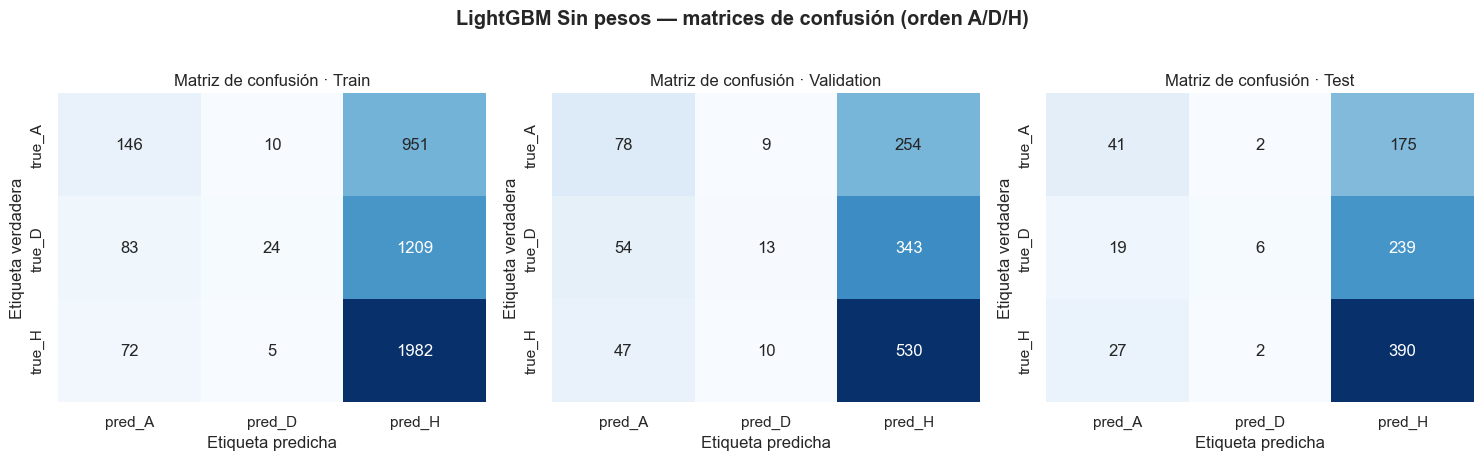

In [10]:
resultados_simple = {
    'Train':      evaluar_split_lgb(lgb_simple, 'LGB', 'Train',      X_train, y_train),
    'Validation': evaluar_split_lgb(lgb_simple, 'LGB', 'Validation', X_val,   y_val),
    'Test':       evaluar_split_lgb(lgb_simple, 'LGB', 'Test',       X_test,  y_test),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, res) in zip(axes, resultados_simple.items()):
    cm = np.array(res['confusion_matrix'])
    graficar_matriz_confusion(cm, LABELS, nombre, ax=ax)
plt.suptitle('LightGBM Sin pesos — matrices de confusión (orden A/D/H)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


Top features (LGB sin pesos):
prob_h               7644.631364
match_uncertainty    1342.558172
home_mv               544.431751
away_gd_pre           473.507448
away_gc_3             443.956739
away_gc_10            360.326109
home_rest_days        347.323190
away_elo_pre          337.345019
home_gd_pre           294.877228
home_elo_pre          256.470870
home_ppg_10           237.566630
away_mv               196.905602
home_gf_5             169.676676
home_pts_pre          167.634189
away_pts_pre          164.916928
away_rest_days        131.979561
away_ppg_3             92.050670
home_gf_3              86.590750
away_gf_3              86.417051
home_gf_10             78.607471
away_ppg_10            73.757930
home_gc_3              70.362630
away_gf_10             68.535130
home_ppg_5             66.398050
home_ppg_3             57.700259
away_pos_pre           44.499399
home_gc_10             38.314570
away_gf_5              33.772150
away_gc_5              21.869560
home_gc_5    

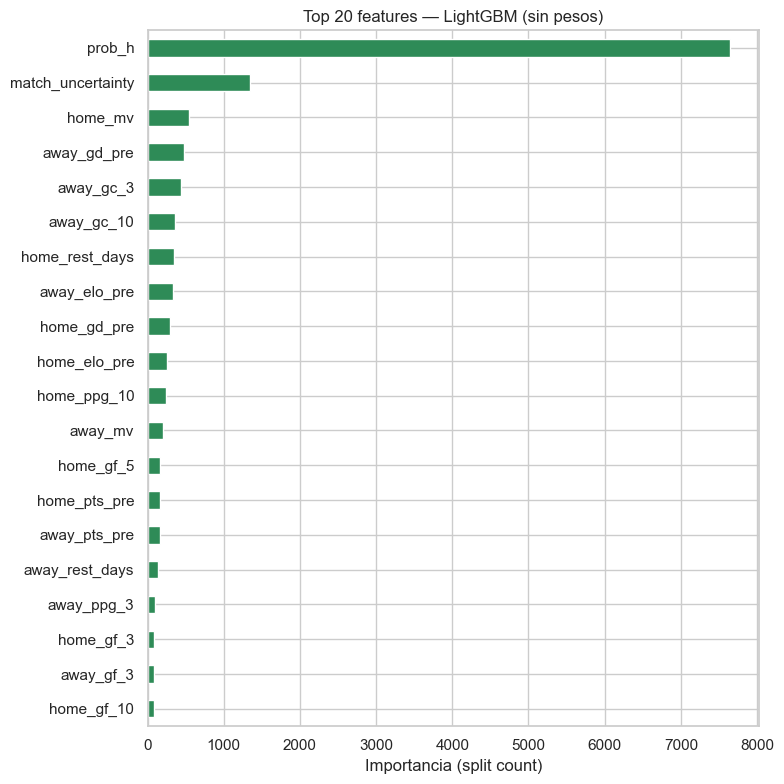

In [14]:
importancias = pd.Series(
    lgb_simple.booster_.feature_importance(importance_type='gain'),
    index=FEATURE_COLS,
).sort_values(ascending=False)


print("Top features (LGB sin pesos):")
print(importancias)

fig, ax = plt.subplots(figsize=(8, 8))
importancias.head(20).iloc[::-1].plot.barh(ax=ax, color='seagreen')
ax.set_title('Top 20 features — LightGBM (sin pesos)')
ax.set_xlabel('Importancia (split count)')
plt.tight_layout()
plt.show()


In [11]:
joblib.dump(lgb_simple, MODELS_DIR / "lgb_simple.pkl")
joblib.dump(lgb_balanced, MODELS_DIR / "lgb_balanced.pkl")

['/Users/pedrosarm/Desktop/TFM/Code/notebooks/models/lgb_balanced.pkl']